In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn import tree


plt.style.use('seaborn-v0_8-whitegrid')

In [85]:
df = pd.read_csv('Titanic_data.csv', dtype={
    'Name': 'str', 'Sex': 'str'
})

In [86]:
df.shape


(891, 12)

In [87]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [88]:
# Get a feel for missing values and data types
print('Missing values:')
print(df.isnull().sum())

print('\nData types:')
print(df.dtypes)

print('\nBasic stats:')
df.describe()

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Basic stats:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [89]:
# Extract Title
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Create FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create 'IsAlone' feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

print(df[['Title', 'FamilySize', 'IsAlone']].head())

  Title  FamilySize  IsAlone
0    Mr           2        0
1   Mrs           2        0
2  Miss           1        1
3   Mrs           2        0
4    Mr           1        1


In [90]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, 
    RocCurveDisplay, classification_report
)
from sklearn.model_selection import cross_val_score

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Comprehensive evaluation report for binary classification.
    """
    # 1. Make Predictions
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1] # Probability of 'Survived' (class 1)

      # 1. Train vs Test
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, y_pred)
    print(f"Train Accuracy : {train_acc:.3f}")
    print(f"Test Accuracy  : {test_acc:.3f}")

    # 2. Calculate Metrics
    # Accuracy: Overall percentage of correct predictions
    acc = accuracy_score(y_test, y_pred)
    
    # Precision: Out of all predicted 'Survived', how many actually did? (Reduces False Positives)
    prec = precision_score(y_test, y_pred)
    
    # Recall: Out of all who actually 'Survived', how many did we find? (Reduces False Negatives)
    rec = recall_score(y_test, y_pred)
    
    # F1 Score: The harmonic mean of Precision and Recall (best for balanced evaluation)
    f1 = f1_score(y_test, y_pred)
    
    # ROC-AUC: Ability of the model to distinguish between classes (1.0 is perfect)
    auc = roc_auc_score(y_test, y_probs)
    
    # Cross-Validation: Check stability by testing on 5 different subsets of the data
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    # 3. Print the Easy-to-Read Report
    print(f" {'='*10} {model_name.upper()} EVALUATION REPORT {'='*10} ")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print(f"CV Mean:   {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print("-" * 50)
    print("Detailed Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

    # 4. Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix: Shows True Positives, True Negatives, False Positives, False Negatives
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax1, cmap='Blues')
    ax1.set_title(f"Confusion Matrix: {model_name}")

    # ROC Curve: Visualizes the trade-off between sensitivity and specificity
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax2)
    ax2.set_title(f"ROC Curve: {model_name}")
    ax2.plot([0, 1], [0, 1], 'k--') # Baseline diagonal line

    plt.tight_layout()
    plt.show()

C:\Users\Chiva\AppData\Local\Temp\ipykernel_37788\2917244634.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='viridis')
C:\Users\Chiva\AppData\Local\Temp\ipykernel_37788\2917244634.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='magma')
C:\Users\Chiva\AppData\Local\Temp\ipykernel_37788\2917244634.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[2], palette='cubehelix')


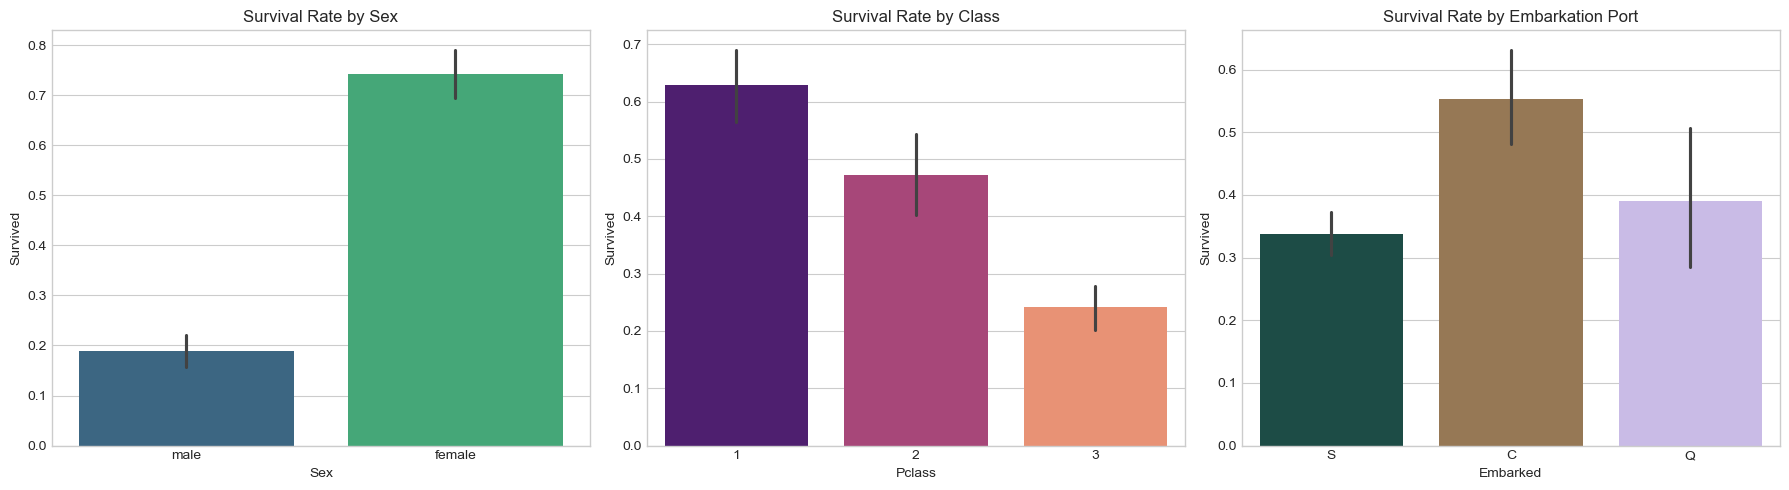

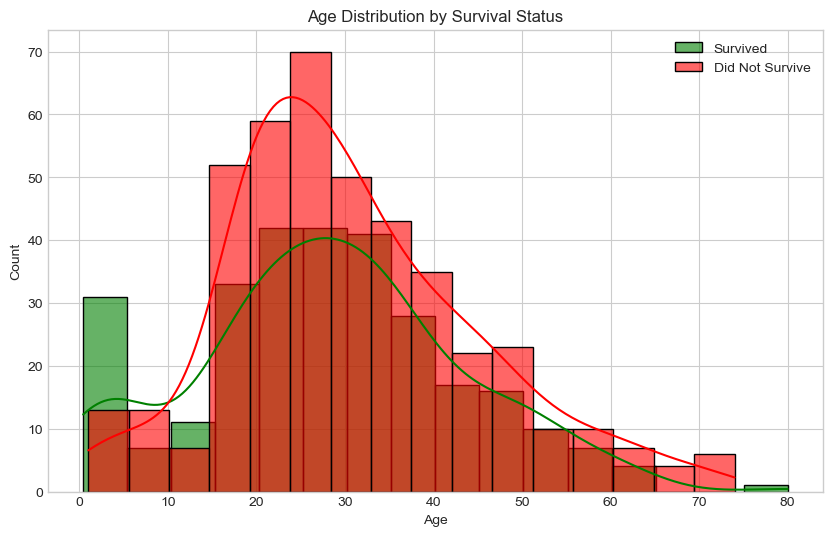

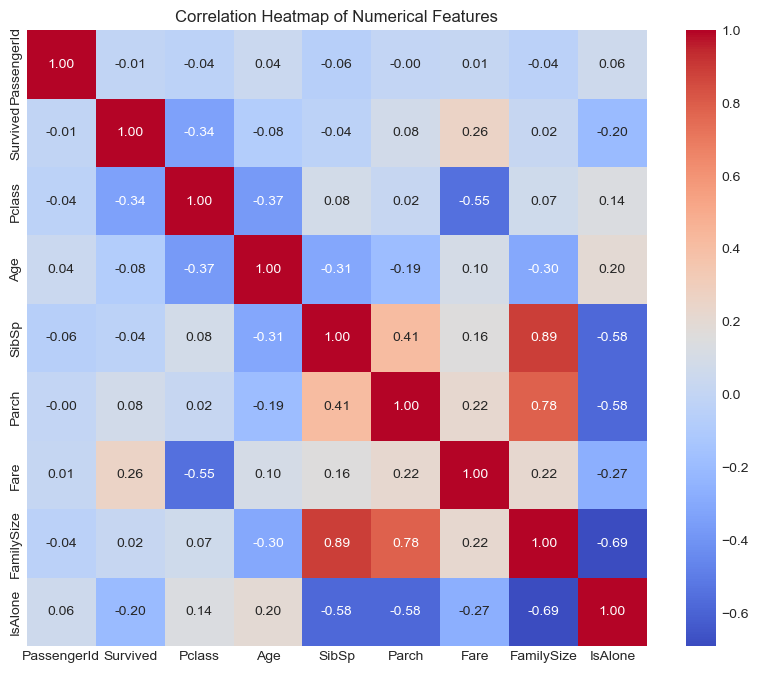

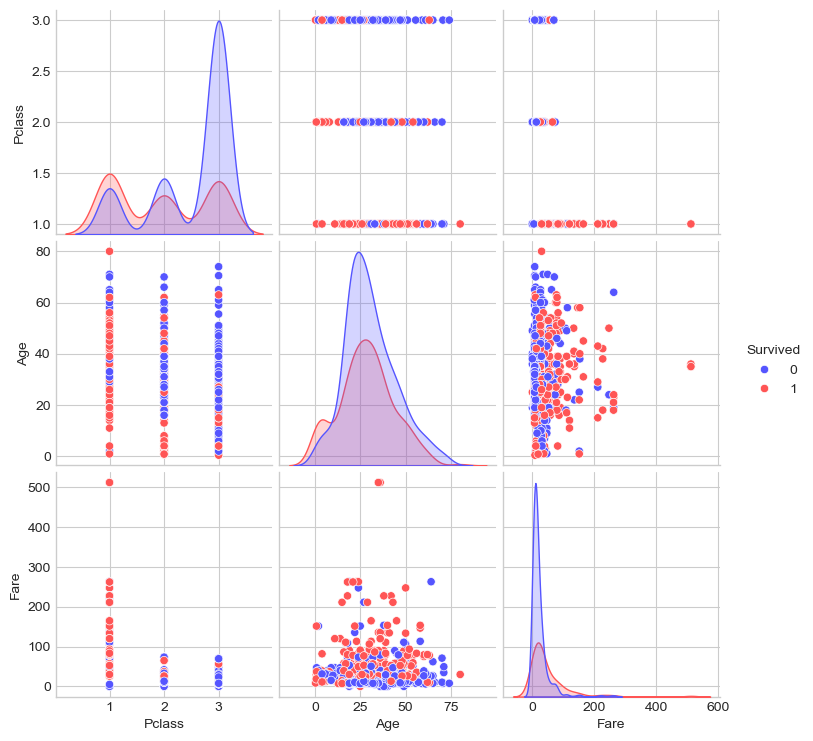

In [91]:

# 1. Survival Distribution by Key Categories
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Survival Rate by Sex')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Survival Rate by Class')

sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[2], palette='cubehelix')
axes[2].set_title('Survival Rate by Embarkation Port')

plt.tight_layout()
plt.show()

# 2. Age Distribution: Survived vs Not Survived
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Survived'] == 1]['Age'], kde=True, color='green', label='Survived', alpha=0.6)
sns.histplot(df[df['Survived'] == 0]['Age'], kde=True, color='red', label='Did Not Survive', alpha=0.6)
plt.title('Age Distribution by Survival Status')
plt.legend()
plt.show()

# 3. Correlation Heatmap (Numerical Features)
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 4. Pairplot to see multi-variable relationships
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']], hue='Survived', palette='seismic')
plt.show()

In [92]:

# 1. Define X and y  
cols_to_drop = ['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'] # getting rid of unecessary columns (they are noise and dont add useful info)
X = df.drop(columns=cols_to_drop)
y = df['Survived']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocess  
X_train = pd.get_dummies(X_train, dummy_na=True)
X_test  = pd.get_dummies(X_test,  dummy_na=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())



decision tree

In [93]:
# Define and fit model  
dt_model = tree.DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [94]:
dt_model.score(X_test, y_test)

0.8324022346368715

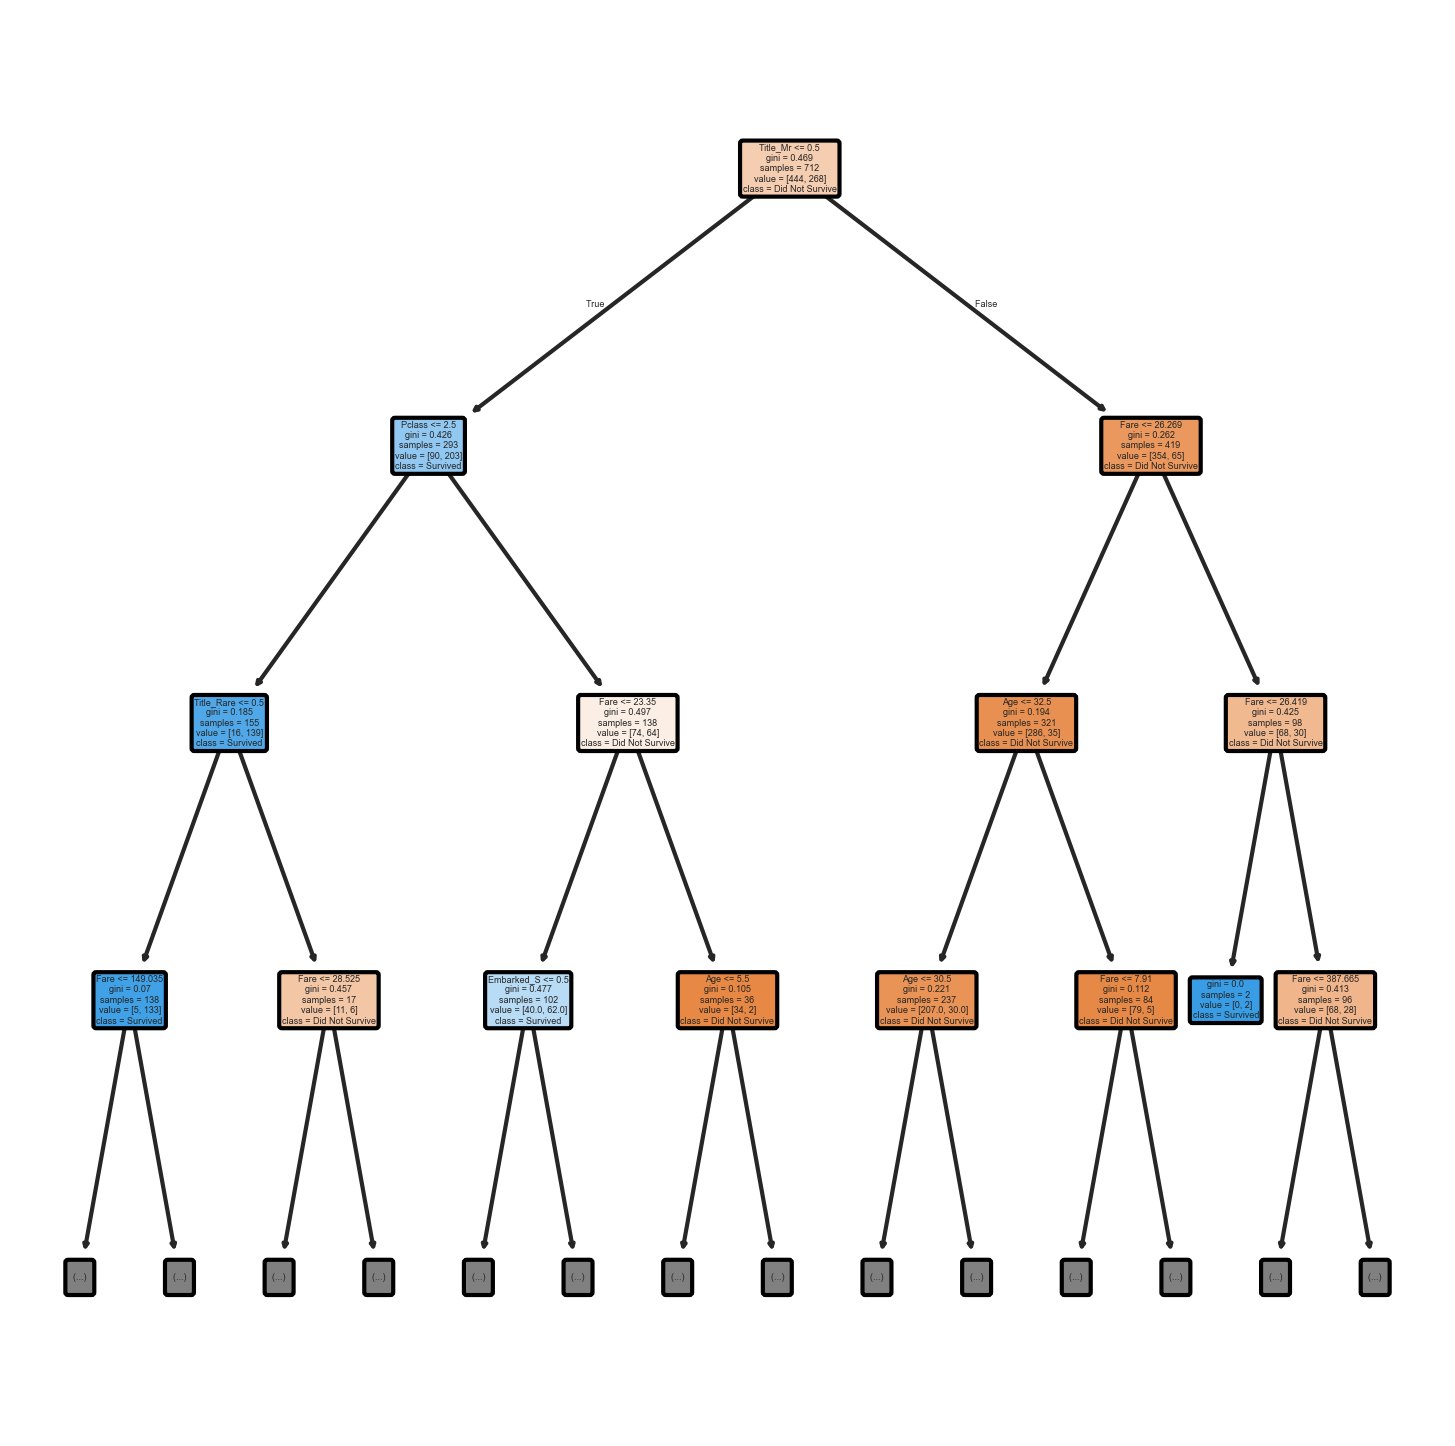

In [95]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), dpi=300)
tree.plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['Did Not Survive', 'Survived'],
    max_depth=3,
    filled=True,
    rounded=True
)
plt.show()

Train Accuracy : 0.843
Test Accuracy  : 0.832
 ========== DECISION TREE EVALUATION REPORT ========== 
Accuracy:  0.8324
Precision: 0.8143
Recall:    0.7703
F1 Score:  0.7917
ROC-AUC:   0.8759
CV Mean:   0.8061 (+/- 0.0514)
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179

--------------------------------------------------


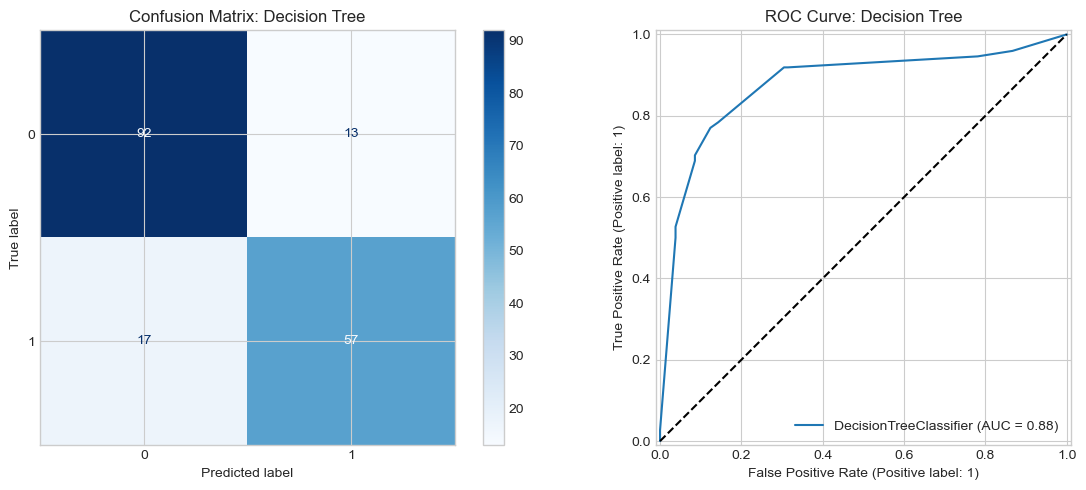

In [96]:
evaluate_model(dt_model, X_train, X_test, y_train, y_test, "Decision Tree")

random forest classifier

In [97]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,   # number of trees
    max_depth=6,        # max depth of each tree
    random_state=42     # for reproducibility
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [98]:
rf_model.score(X_test, y_test)

0.8212290502793296

Train Accuracy : 0.869
Test Accuracy  : 0.821
 ========== RANDOM FOREST EVALUATION REPORT ========== 
Accuracy:  0.8212
Precision: 0.8000
Recall:    0.7568
F1 Score:  0.7778
ROC-AUC:   0.8893
CV Mean:   0.8314 (+/- 0.0327)
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

--------------------------------------------------


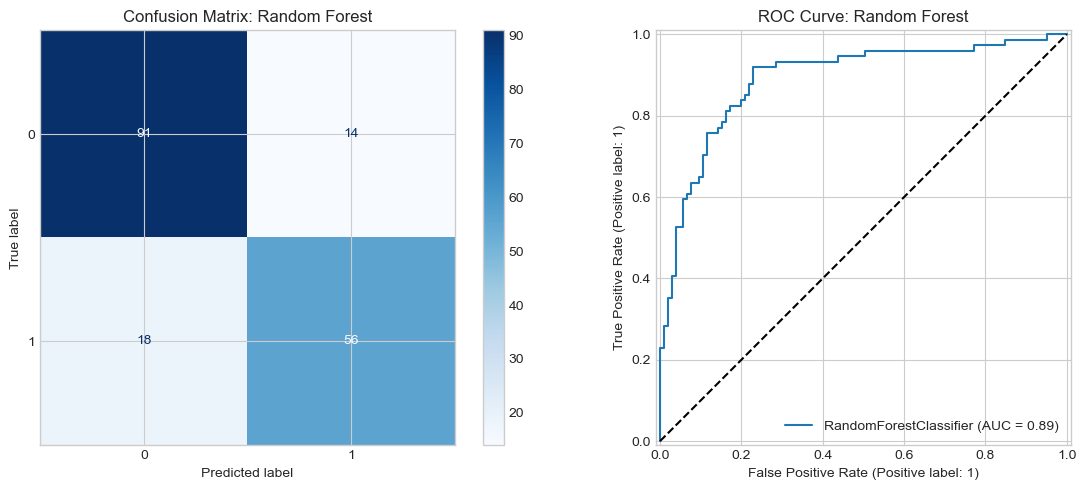

In [99]:
evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest")

logistic regression

In [100]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [101]:
lr_model.score(X_test, y_test)

0.8156424581005587

Train Accuracy : 0.834
Test Accuracy  : 0.816
 ========== LOGISTIC REGRESSION EVALUATION REPORT ========== 
Accuracy:  0.8156
Precision: 0.7808
Recall:    0.7703
F1 Score:  0.7755
ROC-AUC:   0.8907
CV Mean:   0.8300 (+/- 0.0374)
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

--------------------------------------------------


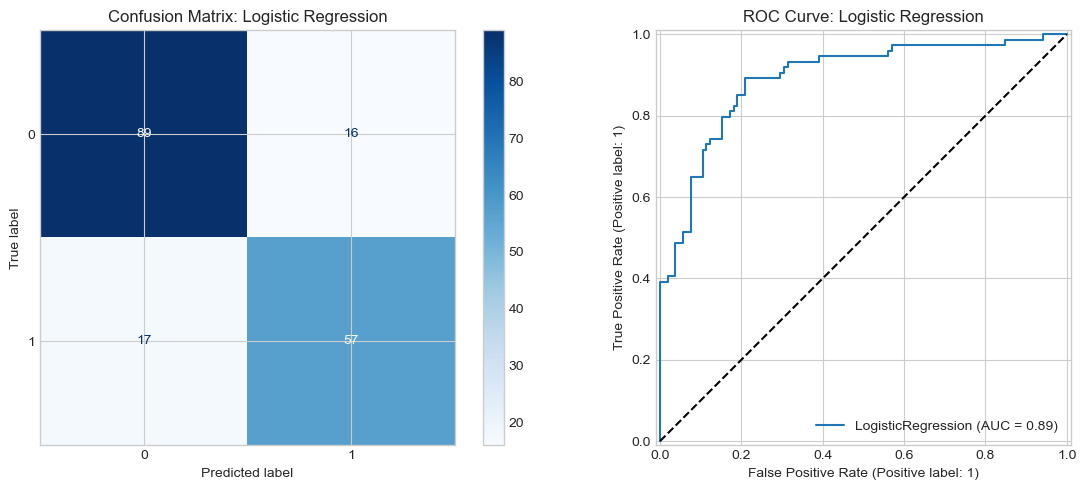

In [102]:
evaluate_model(lr_model, X_train, X_test, y_train, y_test, "Logistic Regression")

final comparison